# Imputación

In [ ]:
import pandas as pd
df = pd.read_csv("LaClosaT.csv")
print(df.head())

   id_nodo             instante    HS10    HS20    HS30   HS40    HS50  \
0        2  2020-03-01 00:01:33  0.6943  0.7429  0.7664  0.774  0.7801   
1        2  2020-03-01 00:10:58  0.6940  0.7429  0.7662  0.774  0.7799   
2        2  2020-03-01 00:20:26  0.6932  0.7429  0.7662  0.774  0.7799   
3        2  2020-03-01 00:25:11  0.6932  0.7429  0.7662  0.774  0.7801   
4        2  2020-03-01 00:29:54  0.6930  0.7426  0.7662  0.774  0.7799   

     HS60   TS30     TA      HA  litros_arbol   año  
0  0.7979  14.68  20.18  0.4929     62.181818  2020  
1  0.7979  14.68  20.10  0.4977     62.181818  2020  
2  0.7981  14.68  19.97  0.5014     62.181818  2020  
3  0.7981  14.68  20.02  0.5070     62.181818  2020  
4  0.7979  14.68  19.99  0.5121     62.181818  2020  


RESAMPLING A 9MIN

In [ ]:
import pandas as pd

df['instante'] = pd.to_datetime(df['instante'])
df = df.set_index('instante')

df = df.drop(columns=['id_nodo', 'año'], errors='ignore')  
# Resample a 9 minutos calculando la media de cada intervalo
df_resampled = df.resample('9min').mean()

print(df_resampled.head())


                       HS10    HS20    HS30   HS40    HS50    HS60   TS30  \
instante                                                                    
2020-03-01 00:00:00  0.6943  0.7429  0.7664  0.774  0.7801  0.7979  14.68   
2020-03-01 00:09:00  0.6940  0.7429  0.7662  0.774  0.7799  0.7979  14.68   
2020-03-01 00:18:00  0.6932  0.7429  0.7662  0.774  0.7800  0.7981  14.68   
2020-03-01 00:27:00  0.6930  0.7426  0.7662  0.774  0.7799  0.7979  14.68   
2020-03-01 00:36:00  0.6935  0.7429  0.7662  0.774  0.7799  0.7979  14.68   

                         TA      HA  litros_arbol  
instante                                           
2020-03-01 00:00:00  20.180  0.4929     62.181818  
2020-03-01 00:09:00  20.100  0.4977     62.181818  
2020-03-01 00:18:00  19.995  0.5042     62.181818  
2020-03-01 00:27:00  19.990  0.5121     62.181818  
2020-03-01 00:36:00  19.720  0.5260     62.181818  


In [ ]:
import pandas as pd

df_filtered = df_resampled[df_resampled.index.month.isin(range(3, 12))]
hs_ha_columns = [col for col in df_filtered.columns if col.startswith("HS") or col.startswith("HA") or col.startswith("T") or col.startswith("litros")]

nulos_por_var_año = df_filtered.groupby(df_filtered.index.year)[hs_ha_columns].apply(lambda x: x.isna().sum())

print("Número de valores nulos por variable y año (marzo-noviembre):")
print(nulos_por_var_año)


Número de valores nulos por variable y año (marzo-noviembre):
           HS10   HS20   HS30   HS40   HS50   HS60   TS30     TA     HA  \
instante                                                                  
2020      11007  11007  11007  11008  11007  11007  11014  13707  13817   
2021      16858  16858  16858  16858  16858  16858  16861  16857  16891   
2022      19954  19955  19949  19950  19949  19949  19953  19949  19951   
2023      12957  12958  12957  12957  12957  12957  12960  12974  12989   

          litros_arbol  
instante                
2020             11005  
2021             16857  
2022             19949  
2023             14653  


IMPUTACION TRAMOS MISMA TENDENCIA HS

In [ ]:
import pandas as pd
import numpy as np

def classify_nan_segment(series, g0, g1, window=3):
    """
    Clasifica un tramo NaN como:
    'uptrend', 'downtrend', 'peak', 'valley' o None
    """
    s = series

    prev = s.iloc[:g0].dropna()
    if len(prev) < window:
        return None

    prev_vals = prev.iloc[-window:]
    prev_times = prev_vals.index

    post = s.iloc[g1 + 1:].dropna()
    if len(post) < window:
        return None

    post_vals = post.iloc[:window]
    post_times = post_vals.index

    x_prev = (prev_times - prev_times[0]).total_seconds()
    x_post = (post_times - post_times[0]).total_seconds()

    y_prev = prev_vals.values
    y_post = post_vals.values

    m_prev = np.polyfit(x_prev, y_prev, 1)[0]
    m_post = np.polyfit(x_post, y_post, 1)[0]

    if m_prev > 0 and m_post > 0:
        return "uptrend"
    elif m_prev < 0 and m_post < 0:
        return "downtrend"
    elif m_prev > 0 and m_post < 0:
        return "peak"
    elif m_prev < 0 and m_post > 0:
        return "valley"

    return None

def interpolate_trends_only(series, window=3):
    s = series.copy()
    idxs = s.index

    isnull = s.isna()
    groups = []
    start = None

    for i in range(len(s)):
        if isnull.iloc[i] and start is None:
            start = i
        elif not isnull.iloc[i] and start is not None:
            groups.append((start, i - 1))
            start = None
    if start is not None:
        groups.append((start, len(s) - 1))

    for g0, g1 in groups:
        label = classify_nan_segment(s, g0, g1, window=window)

        if label not in ["uptrend", "downtrend"]:
            continue

        prev_vals = s.iloc[:g0].dropna()
        post_vals = s.iloc[g1 + 1:].dropna()
        if len(prev_vals) == 0 or len(post_vals) == 0:
            continue

        b = prev_vals.iloc[-1]
        d = post_vals.iloc[0]
        b_time = prev_vals.index[-1]
        d_time = post_vals.index[0]

        T = (d_time - b_time).total_seconds()
        if T <= 0:
            continue

        for i in range(g0, g1 + 1):
            t = (idxs[i] - b_time).total_seconds()
            s.iloc[i] = b + (d - b) * (t / T)

    return s


cols = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]
df_imputed = df_resampled.copy()
for c in cols:
    df_imputed[c] = interpolate_trends_only(df_resampled[c], window=6)



In [ ]:
df_imputed.to_csv("df_imputed.csv", index=True)  # index=True para mantener el DateTimeIndex

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("df_imputed.csv")
df["instante"] = pd.to_datetime(df["instante"])


Imputar tendencia

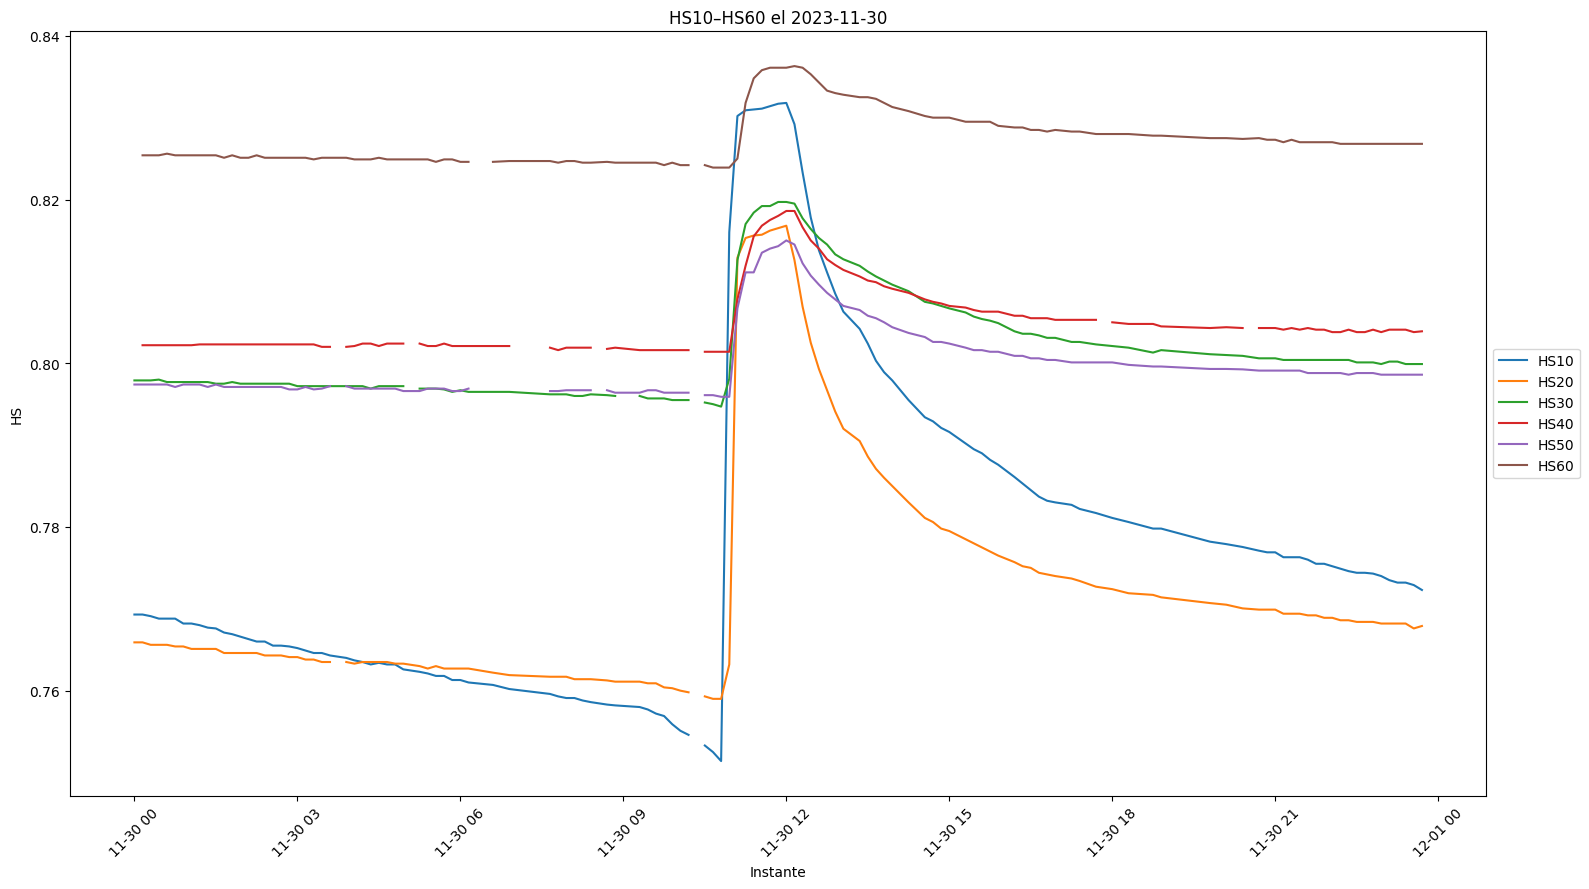

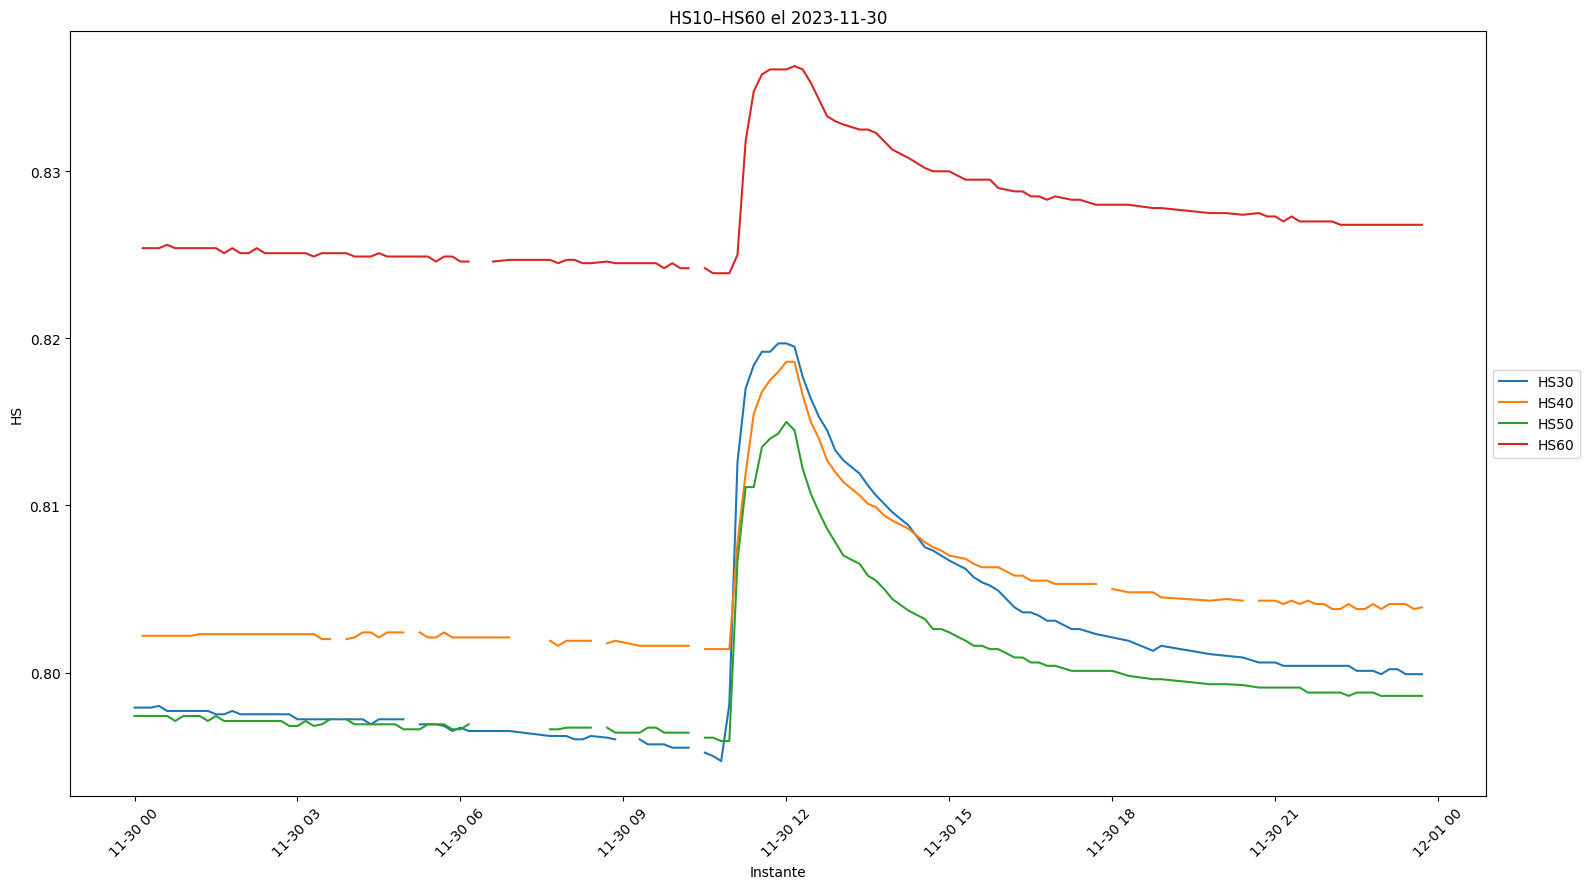

In [ ]:
year = 2023
month = 11
day = 30

df_day = df[
    (df["instante"].dt.year == year) &
    (df["instante"].dt.month == month) &
    (df["instante"].dt.day == day)
]

hs_cols = ["HS10", "HS20", "HS30", "HS40", "HS50", "HS60"]

plt.figure(figsize=(16, 9)) 
for col in hs_cols:
    plt.plot(df_day["instante"], df_day[col], label=col)
plt.xlabel("Instante")
plt.ylabel("HS")
plt.title(f"HS10–HS60 el {year}-{month:02d}-{day:02d}")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.tight_layout()
mng = plt.get_current_fig_manager()
try:
    mng.full_screen_toggle()
except:
    pass  
plt.show()

hs_cols = ["HS30", "HS40", "HS50", "HS60"]

plt.figure(figsize=(16, 9)) 
for col in hs_cols:
    plt.plot(df_day["instante"], df_day[col], label=col)
plt.xlabel("Instante")
plt.ylabel("HS")
plt.title(f"HS10–HS60 el {year}-{month:02d}-{day:02d}")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=45)
plt.tight_layout()
mng = plt.get_current_fig_manager()
try:
    mng.full_screen_toggle()
except:
    pass 
plt.show()

In [ ]:
hs_cols = ["HS10","HS20","HS30","HS40","HS50", "HS60"]

hora_inicio = 0
hora_fin = 23

mask_periodo = (
    (df["instante"].dt.year == year) &
    (df["instante"].dt.month == month) &
    (df["instante"].dt.day == day) &
    (df["instante"].dt.hour >= hora_inicio) &
    (df["instante"].dt.hour <= hora_fin)
)

for col in hs_cols:
    df.loc[mask_periodo, col] = (
        df.loc[mask_periodo, col]
        .interpolate(method="linear", limit_direction="both")
    )


In [ ]:
import pandas as pd
hs_cols = ["HS10", "HS20","HS30", "HS40", "HS50", "HS60"]

hora_inicio = (0, 40)    
hora_fin = (10, 20)      

inicio = pd.Timestamp(year, month, day, hora_inicio[0], hora_inicio[1])
fin = pd.Timestamp(year, month, day, hora_fin[0], hora_fin[1])
mask_periodo = (df["instante"] >= inicio) & (df["instante"] <= fin)

for col in hs_cols:
    df.loc[mask_periodo, col] = (
        df.loc[mask_periodo, col]
        .interpolate(method="linear", limit_direction="both")
    )

In [ ]:
df = pd.read_csv("serienProceso.csv")
df["instante"] = pd.to_datetime(df["instante"])


In [ ]:
df.to_csv("serieHSlimpiaCampoM.csv", index=False)


Comparacion nulos HS antes y despues de interpolar = tendencia

In [ ]:
import pandas as pd

df_filtered = df_resampled[df_resampled.index.month.isin(range(3, 12))]

# Columnas de interés (HS y HA)
hs_ha_columns = [col for col in df_filtered.columns if col.startswith("HS")]

nulos_por_var_año = df_filtered.groupby(df_filtered.index.year)[hs_ha_columns].apply(lambda x: x.isna().sum())

print("Número de valores nulos por variable y año (marzo-noviembre):")
print(nulos_por_var_año)


Número de valores nulos por variable y año (marzo-noviembre):
           HS10   HS20   HS30   HS40   HS50   HS60
instante                                          
2020      11007  11007  11007  11008  11007  11007
2021      16858  16858  16858  16858  16858  16858
2022      19954  19955  19949  19950  19949  19949
2023      12957  12958  12957  12957  12957  12957


In [ ]:
import pandas as pd
df_interpola2 = pd.read_csv("df_interpola2.csv", index_col=0, parse_dates=True)
hs_ha_columns = [col for col in df_interpola2.columns if col.startswith("HS")]

nulos_por_var_año = df_interpola2.groupby(df_interpola2.index.year)[hs_ha_columns].apply(lambda x: x.isna().sum())

print("Número de valores nulos por variable y año (marzo-noviembre):")
print(nulos_por_var_año)

Número de valores nulos por variable y año (marzo-noviembre):
          HS10   HS20   HS30   HS40   HS50   HS60
instante                                         
2020      4013   5664   7438   7942   8378   9953
2021      6890   9341  12548  13143  13693  14957
2022      9365  10963  14130  15940  15824  16538
2023      3506   5009   7836   9820   9606   9689


VER OTRAS VARS TS TA HA LITROS_ARBOL

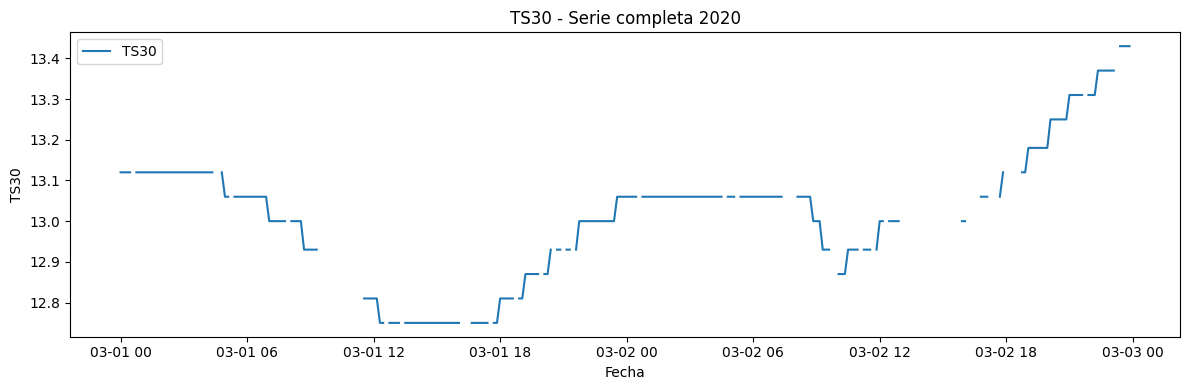

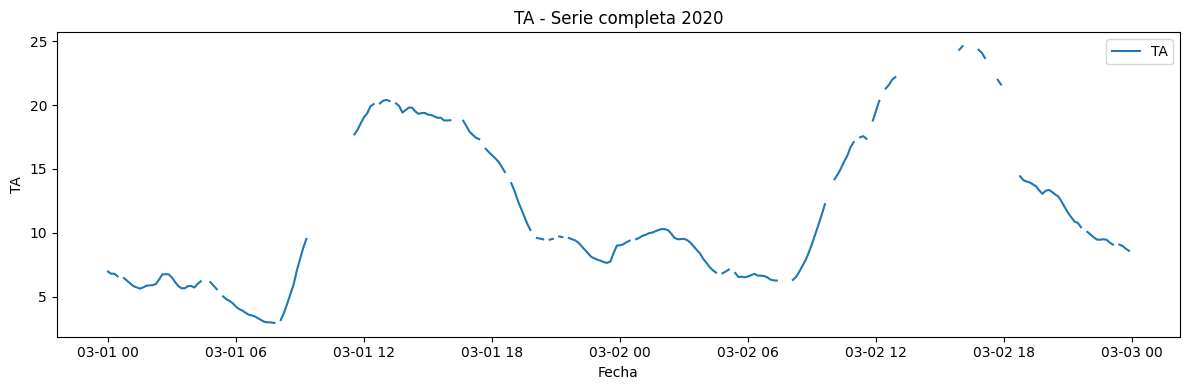

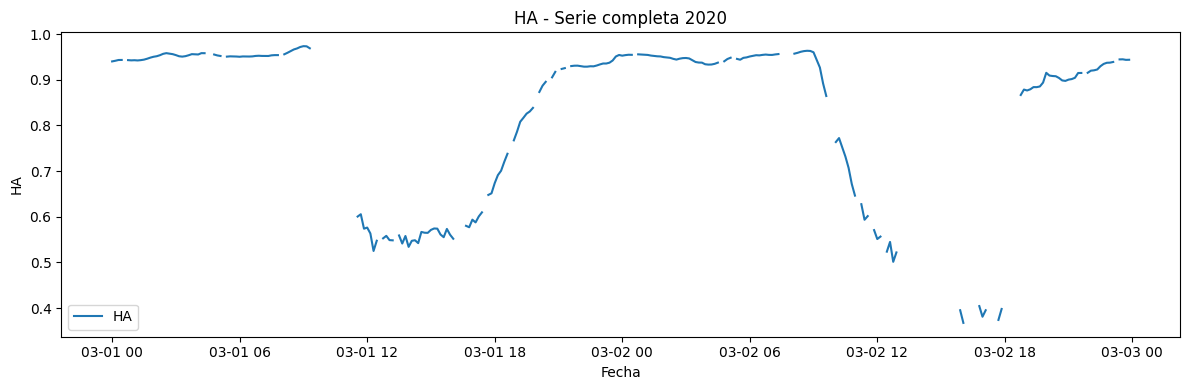

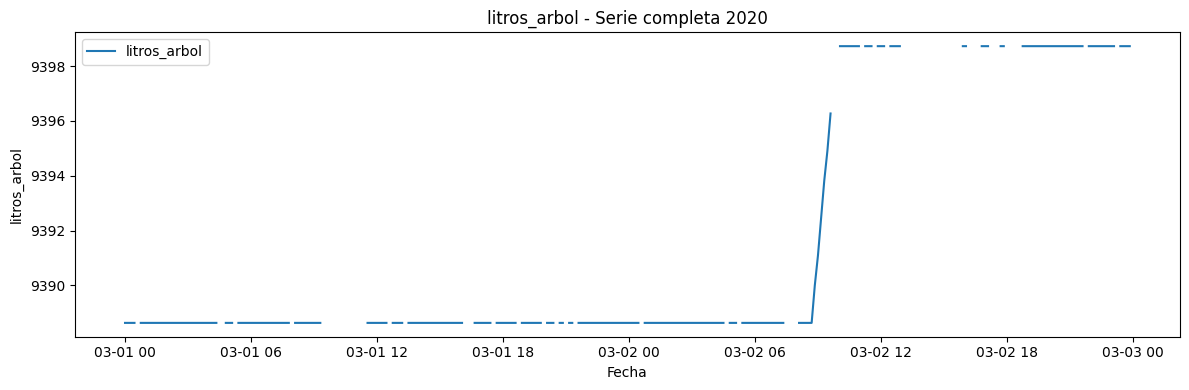

In [ ]:
import matplotlib.pyplot as plt

df_interpola2.index = pd.to_datetime(df_interpola2.index)

vars_plot = ["TS30", "TA", "HA", "litros_arbol"]

df_2020 = df_interpola2.loc["2022-03-01":"2022-03-02"]

for v in vars_plot:
    plt.figure(figsize=(12,4))
    plt.plot(df_2020.index, df_2020[v], label=v)
    plt.xlabel("Fecha")
    plt.ylabel(v)
    plt.title(f"{v} - Serie completa 2020")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
def interpolate_with_rules(series):
    s = series.copy()
    idxs = s.index
    isnull = s.isna()
    groups = []
    start = None

    for i in range(len(s)):
        if isnull.iloc[i] and start is None:
            start = i
        elif not isnull.iloc[i] and start is not None:
            groups.append((start, i - 1))
            start = None

    if start is not None:
        groups.append((start, len(s) - 1))

    for g0, g1 in groups:

        if g0 == 0 or g1 == len(s) - 1:
            continue

        # ------ valores previos ------
        prev_vals = s.iloc[:g0].dropna()
        if len(prev_vals) < 1:
            continue

        b = prev_vals.iloc[-1]
        b_time = prev_vals.index[-1]

        # ------ valores posteriores ------
        post_vals = s.iloc[g1+1:].dropna()
        if len(post_vals) < 1:
            continue

        d = post_vals.iloc[0]
        d_time = post_vals.index[0]

        if b == d:
            for i in range(g0, g1 + 1):
                s.iloc[i] = b
            continue

        if len(prev_vals) < 2 or len(post_vals) < 2:
            continue

        a = prev_vals.iloc[-2]      # penúltimo antes
        e = post_vals.iloc[1]       # segundo después

        increasing = (a < b < d < e)
        decreasing = (a > b > d > e)

        if not (increasing or decreasing):
            continue

        T = (d_time - b_time).total_seconds()
        if T <= 0:
            continue

        for i in range(g0, g1 + 1):
            t = (idxs[i] - b_time).total_seconds()
            s.iloc[i] = b + (d - b) * (t / T)

    return s

cols_extra = ["HA", "TA", "TS30", "litros_arbol"]

df_interpolado = df_interpola2.copy()

for c in cols_extra:
    df_interpolado[c] = interpolate_with_rules(df_interpolado[c])


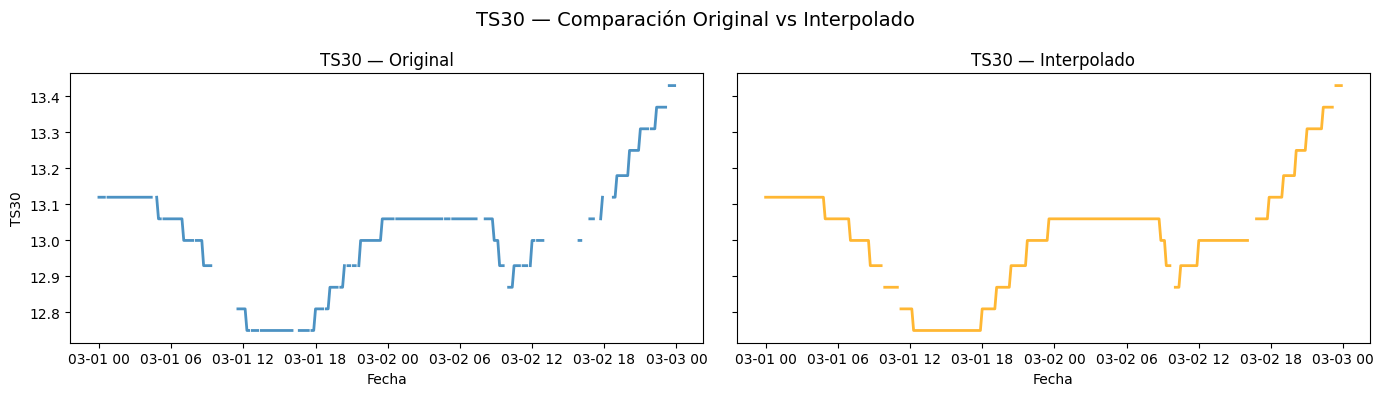

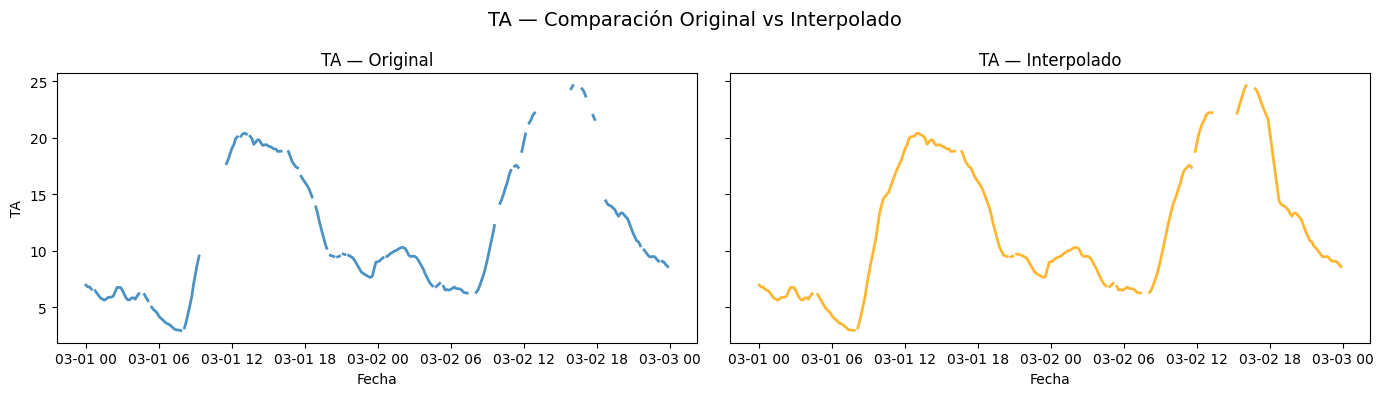

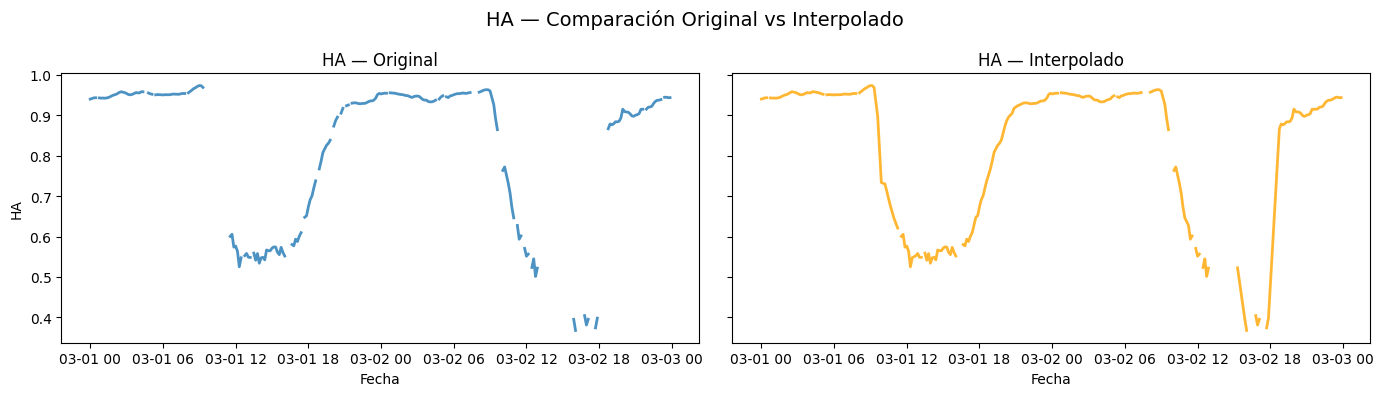

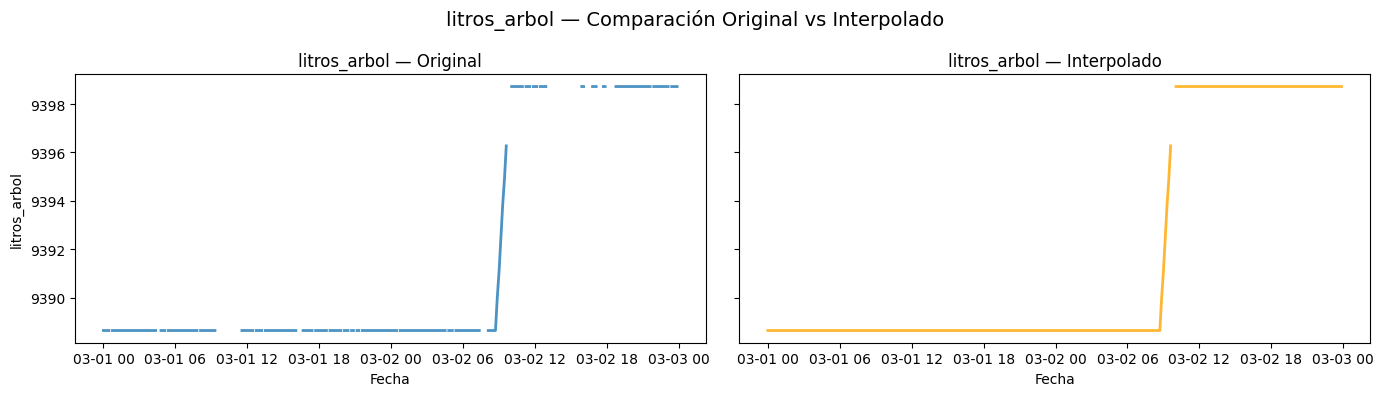

In [ ]:
import matplotlib.pyplot as plt


df_interpola2.index = pd.to_datetime(df_interpola2.index)
df_interpolado.index = pd.to_datetime(df_interpolado.index)

vars_plot = ["TS30", "TA", "HA", "litros_arbol"]

df_2020_orig = df_interpola2.loc["2022-03-01":"2022-03-02"]
df_2020_interp = df_interpolado.loc["2022-03-01":"2022-03-02"]

for v in vars_plot:

    fig, axes = plt.subplots(1, 2, figsize=(14,4), sharey=True)

    axes[0].plot(df_2020_orig.index, df_2020_orig[v], 
                 linewidth=2, alpha=0.8)
    axes[0].set_title(f"{v} — Original")
    axes[0].set_xlabel("Fecha")
    axes[0].set_ylabel(v)

    axes[1].plot(df_2020_interp.index, df_2020_interp[v], 
                 linewidth=2, alpha=0.8, color="orange")
    axes[1].set_title(f"{v} — Interpolado")
    axes[1].set_xlabel("Fecha")

    fig.suptitle(f"{v} — Comparación Original vs Interpolado", fontsize=14)
    plt.tight_layout()
    plt.show()



In [ ]:
import pandas as pd

df_filtered = df_resampled[df_resampled.index.month.isin(range(3, 12))]
columns = [col for col in df_filtered.columns]

nulos_por_var_año = df_filtered.groupby(df_filtered.index.year)[columns].apply(lambda x: x.isna().sum())

print("Número de valores nulos por variable y año (marzo-noviembre):")
print(nulos_por_var_año)


Número de valores nulos por variable y año (marzo-noviembre):
           HS10   HS20   HS30   HS40   HS50   HS60   TS30     TA     HA  \
instante                                                                  
2020      11007  11007  11007  11008  11007  11007  11014  13707  13817   
2021      16858  16858  16858  16858  16858  16858  16861  16857  16891   
2022      19954  19955  19949  19950  19949  19949  19953  19949  19951   
2023      12957  12958  12957  12957  12957  12957  12960  12974  12989   

          litros_arbol  
instante                
2020             11005  
2021             16857  
2022             19949  
2023             12957  


In [ ]:
columns = [col for col in df_interpolado.columns]

nulos_por_var_año = df_interpolado.groupby(df_interpolado.index.year)[columns].apply(lambda x: x.isna().sum())

print("Número de valores nulos por variable y año (marzo-noviembre):")
print(nulos_por_var_año)

Número de valores nulos por variable y año (marzo-noviembre):
          HS10   HS20   HS30   HS40   HS50   HS60  TS30    TA     HA  \
instante                                                               
2020      4013   5664   7438   7942   8378   9953  2695  8446   9364   
2021      6890   9341  12548  13143  13693  14957  5448  9543  10267   
2022      9365  10963  14130  15940  15824  16538  8023  7687   7298   
2023      3506   5009   7836   9820   9606   9689  3734  6499   6763   

          litros_arbol  
instante                
2020               422  
2021              1195  
2022              4677  
2023               804  


In [ ]:
import pandas as pd

df_interpolado.index = pd.to_datetime(df_interpolado.index)

df_mar_nov = df_interpolado[
    (df_interpolado.index.month >= 3) &
    (df_interpolado.index.month <= 11)
]

df_mar_nov.to_csv("df_interpolado_mar_nov.csv", index=True)


MIRAR LOS NAN EN HS RESPECTO OTROS NIVELES

In [ ]:
import pandas as pd

df_mar_nov = pd.read_csv("df_interpolado_mar_nov.csv", index_col=0, parse_dates=True)

hs_cols = [c for c in df_mar_nov.columns if c.startswith('HS')]

result = pd.DataFrame(0, index=hs_cols, columns=hs_cols)

for col_nan in hs_cols:
    for col_notnull in hs_cols:
        if col_nan == col_notnull:
            continue  # saltar la diagonal, no interesa
        mask = df_mar_nov[col_nan].isna() & df_mar_nov[col_notnull].notna()
        result.loc[col_nan, col_notnull] = mask.sum()

result


,HS10,HS20,HS30,HS40,HS50,HS60
HS10,0,3092,1506,1574,1640,1215
HS20,10295,0,1657,1506,1641,1268
HS30,19684,12632,0,2770,2801,2110
HS40,24645,17374,7663,0,4111,3098
HS50,25367,18165,8350,4767,0,2966
HS60,28578,21428,11295,7390,6602,0


In [ ]:
import pandas as pd

frecuencia = df_hora_final['litros_por_hora'].value_counts().sort_index()
tabla_frecuencia = frecuencia.reset_index()
tabla_frecuencia.columns = ['litros_por_hora', 'frecuencia']
tabla_frecuencia['frecuencia_relativa'] = 100 * tabla_frecuencia['frecuencia'] / tabla_frecuencia['frecuencia'].sum()
print(tabla_frecuencia.head(20))


    litros_por_hora  frecuencia  frecuencia_relativa
0          0.000000       24171            91.556818
1          0.136364           1             0.003788
2          0.136364           1             0.003788
3          0.272727           3             0.011364
4          0.272727           4             0.015152
5          0.272727           8             0.030303
6          0.272727           1             0.003788
7          0.272727          12             0.045455
8          0.272727           2             0.007576
9          0.272727           7             0.026515
10         0.272727           2             0.007576
11         0.272727          14             0.053030
12         0.272727          38             0.143939
13         0.272727           1             0.003788
14         0.409091           1             0.003788
15         0.545455           6             0.022727
16         0.545455          31             0.117424
17         0.545455           4             0.

In [ ]:
df_hora_final.to_csv("df_hora_final.csv", index=True)


In [ ]:
import pandas as pd

df_hora_final = pd.read_csv("df_hora_final.csv", index_col=0, parse_dates=True)
nulos_por_col = df_hora_final.isna().sum()
print(nulos_por_col)


HS10_mean          1015
HS10_median        1015
HS10_min           1015
HS10_max           1015
HS10_std           1436
HS10_count            0
HS20_mean          1084
HS20_median        1084
HS20_min           1084
HS20_max           1084
HS20_std           1744
HS20_count            0
HS30_mean          1222
HS30_median        1222
HS30_min           1222
HS30_max           1222
HS30_std           2191
HS30_count            0
HS40_mean          1204
HS40_median        1204
HS40_min           1204
HS40_max           1204
HS40_std           2328
HS40_count            0
HS50_mean          1217
HS50_median        1217
HS50_min           1217
HS50_max           1217
HS50_std           2340
HS50_count            0
HS60_mean          1236
HS60_median        1236
HS60_min           1236
HS60_max           1236
HS60_std           2438
HS60_count            0
TS30_mean          1138
TS30_median        1138
TS30_min           1138
TS30_max           1138
TS30_std           1382
TS30_count      